# COMP8221 Advanced Machine Learning Assignment 1

- Student Name: MD IFTHEKHER UDDIN CHY
- Student ID: 48546356
- Unit: COMP8221 Advanced Machine Learning
- Assignment 1
- Option 3: Diffusion Models
- Model: DDIM
- Framework: PyTorch
- Dataset: CIFAR-10

## Assignment Compliance Statement

This notebook will implement only one assignment option: Option 3, Diffusion Models. The selected model is DDIM rather than standard DDPM. The core model will be implemented from scratch using PyTorch and `torch.nn` layers. No HuggingFace `diffusers`, `timm`, or ready-made generative model libraries will be used.

In [1]:
import os
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Selected device: {device}")

PROJECT_ROOT = Path("..").resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR = PROJECT_ROOT / "data"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for directory in [OUTPUT_DIR, DATA_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
    print(f"Directory ready: {directory}")

Selected device: mps
Directory ready: /Users/ifthekher/Downloads/COMP8221_ASSIGNMENTS/ASSIGNMENT_1/COMP8221_Assignment1/outputs
Directory ready: /Users/ifthekher/Downloads/COMP8221_ASSIGNMENTS/ASSIGNMENT_1/COMP8221_Assignment1/data
Directory ready: /Users/ifthekher/Downloads/COMP8221_ASSIGNMENTS/ASSIGNMENT_1/COMP8221_Assignment1/checkpoints


In [3]:
config = {
    "dataset_name": "CIFAR-10",
    "image_size": 32,
    "channels": 3,
    "batch_size": 64,
    "num_workers": 2,
    "pin_memory": True if device.type == "cuda" else False,
    "train_val_split": 0.9,
    "learning_rate": 2e-4,
    "num_epochs": 10,
    "timesteps": 1000,
    "sampling_timesteps": 50,
    "beta_start": 1e-4,
    "beta_end": 0.02,
    "base_channels": 64,
    "seed": SEED,
    "data_dir": "../data",
    "output_dir": "../outputs",
    "checkpoint_dir": "../checkpoints",
    "real_samples_path": "../outputs/real_samples_grid.png",
}

pd.DataFrame(config.items(), columns=["Key", "Value"])

,Key,Value
0,dataset_name,CIFAR-10
1,image_size,32
2,channels,3
3,batch_size,64
4,num_workers,2
5,pin_memory,False
6,train_val_split,0.9
7,learning_rate,0.0002
8,num_epochs,10
9,timesteps,1000


## Dataset Choice and Justification

CIFAR-10 is selected for this DDIM diffusion experiment. It contains small 32x32 RGB natural images, making it suitable for image generation because the samples include meaningful object structure, colour, and visual variation.

Compared with very simple grayscale datasets such as MNIST, CIFAR-10 is more challenging while still being computationally manageable. Its 32x32 resolution is realistic for limited student compute on CPU, Mac MPS, or CUDA hardware.

The images will be scaled to [-1, 1], which is required for diffusion models. Random horizontal flipping is used as light augmentation because it improves variation without destroying the spatial structure of natural images. This section targets the dataset selection and preprocessing requirement of the assignment.

In [4]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset_full = datasets.CIFAR10(
    root=config["data_dir"],
    train=True,
    download=True,
    transform=train_transform,
)

val_dataset_full = datasets.CIFAR10(
    root=config["data_dir"],
    train=True,
    download=True,
    transform=test_transform,
)

test_dataset = datasets.CIFAR10(
    root=config["data_dir"],
    train=False,
    download=True,
    transform=test_transform,
)

train_size = int(config["train_val_split"] * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, _ = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

_, val_dataset = random_split(
    val_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=config["num_workers"],
    pin_memory=config["pin_memory"],
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=config["pin_memory"],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=config["pin_memory"],
)

images, labels = next(iter(train_loader))

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")
print(f"First batch min pixel value: {images.min().item():.3f}")
print(f"First batch max pixel value: {images.max().item():.3f}")

assert images.min().item() >= -1.01 and images.max().item() <= 1.01

/Users/ifthekher/Downloads/COMP8221_ASSIGNMENTS/ASSIGNMENT_1/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Number of training images: 45000
Number of validation images: 5000
Number of test images: 10000
Batch image shape: torch.Size([64, 3, 32, 32])
Batch label shape: torch.Size([64])
First batch min pixel value: -1.000
First batch max pixel value: 1.000


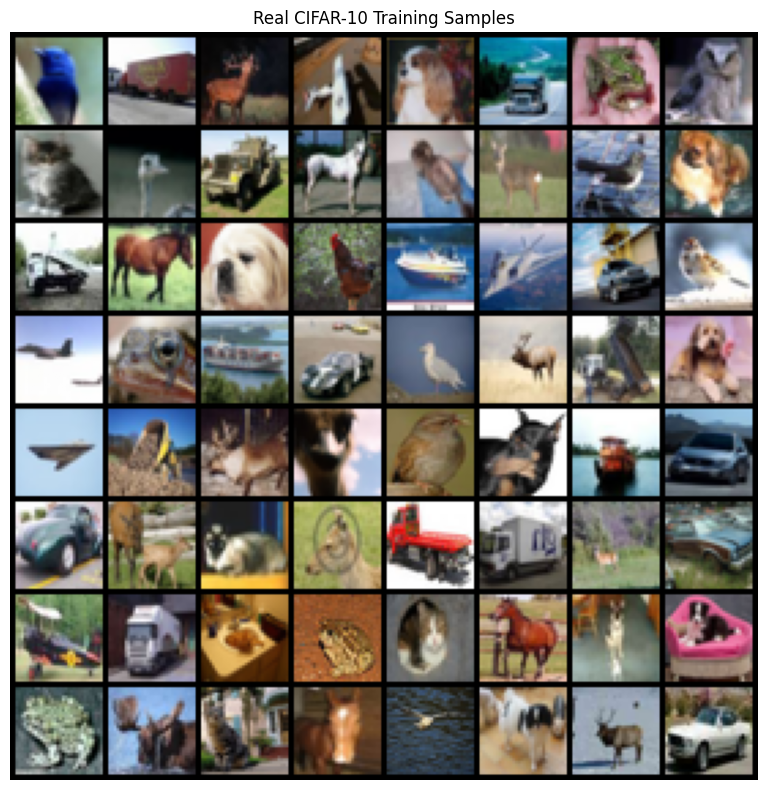

Saved real sample grid to: ../outputs/real_samples_grid.png


In [5]:
sample_images, _ = next(iter(train_loader))
sample_images = sample_images[:64]

def unnormalize_to_01(x):
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)

grid = make_grid(unnormalize_to_01(sample_images), nrow=8, padding=2)
real_samples_path = Path(config["real_samples_path"])
real_samples_path.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Real CIFAR-10 Training Samples")
plt.tight_layout()
plt.savefig(real_samples_path, dpi=200, bbox_inches="tight")
plt.show()

assert real_samples_path.exists()
print(f"Saved real sample grid to: {real_samples_path}")

## DDIM Theory Summary

Diffusion models learn to generate images by reversing a gradual noising process. During training, a clean image $x_0$ is corrupted into $x_t$ by adding Gaussian noise at a randomly sampled timestep $t$, and the neural network learns to predict the added noise $\epsilon$.

This assignment uses a U-Net noise prediction model with sinusoidal time embeddings, so the network can estimate $\epsilon_\theta(x_t, t)$ while being conditioned on the current noise level. DDIM is used as the selected non-standard diffusion variant. It differs from standard DDPM because DDIM modifies the reverse sampling process and can use fewer sampling steps. DDIM can also be deterministic when $\eta = 0$.

This makes DDIM valid for the assignment because standard DDPM is not used as the final sampling method.

In [6]:
class SinusoidalTimeEmbedding(nn.Module):
    """Sinusoidal timestep embeddings implemented from scratch in PyTorch."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, timesteps):
        half_dim = (self.dim + 1) // 2
        exponent = -math.log(10000.0) * torch.arange(
            half_dim,
            device=timesteps.device,
            dtype=torch.float32,
        ) / max(half_dim - 1, 1)
        frequencies = torch.exp(exponent)
        angles = timesteps.float().unsqueeze(1) * frequencies.unsqueeze(0)
        embeddings = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)
        return embeddings[:, :self.dim]


dummy_timesteps = torch.tensor([0, 1, 10], device=device)
time_embedding = SinusoidalTimeEmbedding(dim=64).to(device)
dummy_embedding = time_embedding(dummy_timesteps)

print(f"Time embedding output shape: {dummy_embedding.shape}")
assert dummy_embedding.shape == (3, 64)

Time embedding output shape: torch.Size([3, 64])


In [7]:
def _num_groups(channels):
    """Choose a GroupNorm group count that divides the channel count."""
    for groups in [8, 4, 2, 1]:
        if channels % groups == 0:
            return groups
    return 1


class ConvBlock(nn.Module):
    """Two-layer convolution block with optional timestep conditioning."""

    def __init__(self, in_channels, out_channels, time_emb_dim=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(_num_groups(out_channels), out_channels)
        self.act1 = nn.SiLU()
        self.time_proj = nn.Linear(time_emb_dim, out_channels) if time_emb_dim is not None else None
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(_num_groups(out_channels), out_channels)
        self.act2 = nn.SiLU()

    def forward(self, x, time_emb=None):
        h = self.conv1(x)
        h = self.norm1(h)

        if self.time_proj is not None and time_emb is not None:
            time_features = self.time_proj(time_emb).unsqueeze(-1).unsqueeze(-1)
            h = h + time_features

        h = self.act1(h)
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act2(h)
        return h


class DownBlock(nn.Module):
    """U-Net encoder block that returns the downsampled tensor and a skip tensor."""

    def __init__(self, in_channels, out_channels, time_emb_dim=None):
        super().__init__()
        self.block = ConvBlock(in_channels, out_channels, time_emb_dim)
        self.downsample = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=1)

    def forward(self, x, time_emb=None):
        skip = self.block(x, time_emb)
        x = self.downsample(skip)
        return x, skip


class UpBlock(nn.Module):
    """U-Net decoder block that upsamples, concatenates a skip tensor, and refines."""

    def __init__(self, in_channels, out_channels, time_emb_dim=None):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=4, stride=2, padding=1)
        self.block = ConvBlock(in_channels * 2, out_channels, time_emb_dim)

    def forward(self, x, skip, time_emb=None):
        x = self.upsample(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        x = torch.cat([x, skip], dim=1)
        return self.block(x, time_emb)

In [8]:
class SimpleUNet(nn.Module):
    """Small U-Net noise predictor for 32x32 CIFAR-10 diffusion experiments."""

    def __init__(self, image_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        self.init_conv = nn.Conv2d(image_channels, base_channels, kernel_size=3, padding=1)

        self.time_embedding = SinusoidalTimeEmbedding(time_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.down1 = DownBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4, time_emb_dim)

        self.bottleneck1 = ConvBlock(base_channels * 4, base_channels * 4, time_emb_dim)
        self.bottleneck2 = ConvBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        self.up1 = UpBlock(base_channels * 4, base_channels * 2, time_emb_dim)
        self.up2 = UpBlock(base_channels * 2, base_channels, time_emb_dim)

        self.final_conv = nn.Conv2d(base_channels, image_channels, kernel_size=1)

    def forward(self, x, timesteps):
        # Time embeddings condition the model on the current noise level.
        time_emb = self.time_mlp(self.time_embedding(timesteps))

        x = self.init_conv(x)
        x, skip1 = self.down1(x, time_emb)
        x, skip2 = self.down2(x, time_emb)

        x = self.bottleneck1(x, time_emb)
        x = self.bottleneck2(x, time_emb)

        x = self.up1(x, skip2, time_emb)
        x = self.up2(x, skip1, time_emb)

        # The model predicts epsilon_theta(x_t, t), not a denoised image.
        # Output shape matches input because the loss compares predicted noise with true noise.
        return self.final_conv(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
model = SimpleUNet(
    image_channels=config["channels"],
    base_channels=config["base_channels"],
    time_emb_dim=256,
).to(device)

dummy_images = torch.randn(4, 3, 32, 32, device=device)
dummy_timesteps = torch.randint(0, config["timesteps"], (4,), device=device)

model.eval()
with torch.no_grad():
    output = model(dummy_images, dummy_timesteps)

total_trainable_parameters = count_parameters(model)

print(f"Model name: {model.__class__.__name__}")
print(f"Selected device: {device}")
print(f"Input shape: {dummy_images.shape}")
print(f"Timestep shape: {dummy_timesteps.shape}")
print(f"Output shape: {output.shape}")
print(f"Total trainable parameters: {total_trainable_parameters:,}")

assert output.shape == dummy_images.shape
assert output.dtype == dummy_images.dtype
assert torch.isfinite(output).all()

print("U-Net sanity check passed: output shape matches input shape.")

Model name: SimpleUNet
Selected device: mps
Input shape: torch.Size([4, 3, 32, 32])
Timestep shape: torch.Size([4])
Output shape: torch.Size([4, 3, 32, 32])
Total trainable parameters: 6,855,299
U-Net sanity check passed: output shape matches input shape.


In [10]:
timesteps = config["timesteps"]
beta_start = config["beta_start"]
beta_end = config["beta_end"]

# Linear beta schedule used for the forward noising process.
betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([
    torch.ones(1, device=device),
    alphas_cumprod[:-1],
])

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)


def extract(a, t, x_shape):
    """Gather timestep coefficients and reshape for image broadcasting."""
    batch_size = t.shape[0]
    t = t.to(device=a.device, dtype=torch.long)
    values = a.gather(0, t)
    return values.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


print(f"betas shape: {betas.shape}")
print(f"alphas_cumprod shape: {alphas_cumprod.shape}")
print(f"first beta: {betas[0].item():.6f}")
print(f"last beta: {betas[-1].item():.6f}")
print(f"first alpha_bar: {alphas_cumprod[0].item():.6f}")
print(f"last alpha_bar: {alphas_cumprod[-1].item():.6f}")

assert betas.shape[0] == config["timesteps"]
assert torch.all((betas > 0) & (betas < 1)).item()
assert torch.all(alphas_cumprod[1:] <= alphas_cumprod[:-1]).item()

print("Diffusion schedule setup passed sanity checks.")

betas shape: torch.Size([1000])
alphas_cumprod shape: torch.Size([1000])
first beta: 0.000100
last beta: 0.020000
first alpha_bar: 0.999900
last alpha_bar: 0.000040
Diffusion schedule setup passed sanity checks.


In [11]:
def q_sample(x_start, t, noise=None):
    """
    Forward diffusion process:
    q(x_t | x_0) = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)
    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise


clean_images, _ = next(iter(train_loader))
clean_images = clean_images[:4].to(device)
batch_size = clean_images.shape[0]
random_timesteps = torch.randint(0, config["timesteps"], (batch_size,), device=device)
noisy_images = q_sample(clean_images, random_timesteps)

print(f"Clean image shape: {clean_images.shape}")
print(f"Noisy image shape: {noisy_images.shape}")
print(f"Timestep shape: {random_timesteps.shape}")
print(f"Noisy image min value: {noisy_images.min().item():.3f}")
print(f"Noisy image max value: {noisy_images.max().item():.3f}")

assert noisy_images.shape == clean_images.shape
assert torch.isfinite(noisy_images).all().item()

print("q_sample sanity check passed: noisy image shape matches clean image shape.")

Clean image shape: torch.Size([4, 3, 32, 32])
Noisy image shape: torch.Size([4, 3, 32, 32])
Timestep shape: torch.Size([4])
Noisy image min value: -3.839
Noisy image max value: 3.953
q_sample sanity check passed: noisy image shape matches clean image shape.


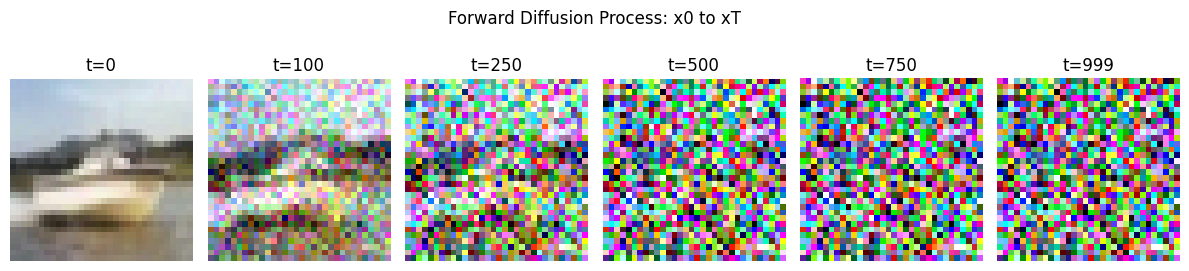

Saved forward noising grid to: ../outputs/forward_noising_grid.png


In [12]:
if "unnormalize_to_01" not in globals():
    def unnormalize_to_01(x):
        return ((x + 1.0) / 2.0).clamp(0.0, 1.0)


clean_batch, _ = next(iter(train_loader))
clean_image = clean_batch[:1].to(device)

selected_timesteps = [
    0,
    min(100, config["timesteps"] - 1),
    min(250, config["timesteps"] - 1),
    min(500, config["timesteps"] - 1),
    min(750, config["timesteps"] - 1),
    config["timesteps"] - 1,
]

# Reuse one noise tensor so the noising trajectory is visually consistent.
fixed_noise = torch.randn_like(clean_image)
noising_steps = []

for timestep in selected_timesteps:
    t = torch.tensor([timestep], device=device, dtype=torch.long)
    x_t = q_sample(clean_image, t, noise=fixed_noise)
    noising_steps.append(unnormalize_to_01(x_t.detach().cpu()[0]))

forward_noising_path = Path("../outputs/forward_noising_grid.png")
forward_noising_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, len(noising_steps), figsize=(12, 3))
for ax, image, timestep in zip(axes, noising_steps, selected_timesteps):
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_title(f"t={timestep}")
    ax.axis("off")

fig.suptitle("Forward Diffusion Process: x0 to xT")
plt.tight_layout()
plt.savefig(forward_noising_path, dpi=200, bbox_inches="tight")
plt.show()

assert forward_noising_path.exists()
print(f"Saved forward noising grid to: {forward_noising_path}")

In [13]:
def noise_prediction_loss(model, x_start):
    """
    Simplified diffusion loss:
    1. sample random timestep t
    2. sample Gaussian noise epsilon
    3. create noisy image x_t using q_sample
    4. predict noise epsilon_theta(x_t, t)
    5. compute MSE between predicted noise and true noise
    """
    x_start = x_start.to(device)
    batch_size = x_start.shape[0]
    t = torch.randint(0, config["timesteps"], (batch_size,), device=x_start.device).long()
    noise = torch.randn_like(x_start)
    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = model(x_noisy, t)
    loss = F.mse_loss(predicted_noise, noise)
    return loss


def compute_loss_components(model, x_start):
    """Return lightweight diagnostics for the noise prediction objective."""
    x_start = x_start.to(device)
    batch_size = x_start.shape[0]
    t = torch.randint(0, config["timesteps"], (batch_size,), device=x_start.device).long()
    noise = torch.randn_like(x_start)
    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = model(x_noisy, t)
    loss = F.mse_loss(predicted_noise, noise)

    return {
        "loss": loss,
        "sampled_timesteps_min": t.min().item(),
        "sampled_timesteps_max": t.max().item(),
        "predicted_noise_shape": tuple(predicted_noise.shape),
        "true_noise_shape": tuple(noise.shape),
    }


sample_images, _ = next(iter(train_loader))
sample_images = sample_images[:4].to(device)

model.train()
model.zero_grad(set_to_none=True)

loss = noise_prediction_loss(model, sample_images)
print(f"Noise prediction loss value: {loss.item():.6f}")

assert loss.ndim == 0
assert torch.isfinite(loss).item()

# One backward pass only checks that gradients can flow through the objective.
loss.backward()
has_gradient = any(
    parameter.grad is not None
    for parameter in model.parameters()
    if parameter.requires_grad
)
assert has_gradient

with torch.no_grad():
    loss_components = compute_loss_components(model, sample_images)

print("Loss diagnostics:")
for key, value in loss_components.items():
    if key == "loss":
        print(f"  {key}: {value.item():.6f}")
    else:
        print(f"  {key}: {value}")

model.zero_grad(set_to_none=True)
print("Noise prediction loss sanity check passed.")

Noise prediction loss value: 1.195402
Loss diagnostics:
  loss: 1.208036
  sampled_timesteps_min: 53
  sampled_timesteps_max: 787
  predicted_noise_shape: (4, 3, 32, 32)
  true_noise_shape: (4, 3, 32, 32)
Noise prediction loss sanity check passed.


In [14]:
# Re-initialize the model cleanly before the later training stage.
model = SimpleUNet(
    image_channels=config["channels"],
    base_channels=config["base_channels"],
    time_emb_dim=256,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=1e-4,
)

scheduler = None
train_losses = []
val_losses = []
epoch_times = []

checkpoint_path = Path(config["checkpoint_dir"]) / "ddim_unet_final.pt"


def save_checkpoint(model, optimizer, epoch, train_losses, val_losses, path):
    """Save model, optimizer, history, and config for reproducible continuation."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "config": config,
        },
        path,
    )


def load_checkpoint(model, optimizer, path, map_location=device):
    """Load a checkpoint if it exists, otherwise return None."""
    path = Path(path)
    if not path.exists():
        print(f"No checkpoint found at: {path}")
        return None

    checkpoint = torch.load(path, map_location=map_location)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"Loaded checkpoint from: {path}")
    return checkpoint


print(f"Model class: {model.__class__.__name__}")
print(f"Device: {device}")
print(f"Total trainable parameters: {count_parameters(model):,}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {config['learning_rate']}")
print(f"Weight decay: {optimizer.param_groups[0]['weight_decay']}")
print(f"Checkpoint path: {checkpoint_path}")

assert next(model.parameters()).device.type == device.type
assert len(optimizer.param_groups) > 0
assert sum(len(group["params"]) for group in optimizer.param_groups) > 0
assert train_losses == [] and val_losses == []
assert checkpoint_path.parent.exists()

print("Optimizer and training utilities are ready. No training has been run yet.")

Model class: SimpleUNet
Device: mps
Total trainable parameters: 6,855,299
Optimizer: AdamW
Learning rate: 0.0002
Weight decay: 0.0001
Checkpoint path: ../checkpoints/ddim_unet_final.pt
Optimizer and training utilities are ready. No training has been run yet.


In [15]:
import time


def run_validation_loss(model, val_loader, max_batches=20):
    """Evaluate a limited number of validation batches for fast feedback."""
    model.eval()
    losses = []

    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(val_loader):
            if batch_idx >= max_batches:
                break

            images = images.to(device)
            loss = noise_prediction_loss(model, images)
            losses.append(loss.item())

    model.train()
    return float(np.mean(losses))


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    num_epochs,
    max_train_batches=None,
    max_val_batches=20,
):
    """Train the noise predictor and log average train/validation losses."""
    model.train()

    for epoch in range(num_epochs):
        start_time = time.perf_counter()
        batch_losses = []
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

        for batch_idx, (images, _) in enumerate(progress_bar):
            if max_train_batches is not None and batch_idx >= max_train_batches:
                break

            images = images.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = noise_prediction_loss(model, images)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_loss = loss.item()
            batch_losses.append(batch_loss)
            progress_bar.set_postfix(loss=f"{batch_loss:.4f}")

        avg_train_loss = float(np.mean(batch_losses))
        avg_val_loss = run_validation_loss(model, val_loader, max_batches=max_val_batches)
        elapsed_time = time.perf_counter() - start_time

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        epoch_times.append(elapsed_time)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f} | "
            f"Time: {elapsed_time:.2f} sec"
        )

        save_checkpoint(
            model,
            optimizer,
            epoch + 1,
            train_losses,
            val_losses,
            checkpoint_path,
        )

    return train_losses, val_losses


RUN_FULL_TRAINING = True
QUICK_TEST_TRAINING = False

if QUICK_TEST_TRAINING:
    print("Running quick test training: 1 epoch, 2 training batches, 2 validation batches.")
    train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        num_epochs=1,
        max_train_batches=2,
        max_val_batches=2,
    )

if RUN_FULL_TRAINING:
    print(f"Running full training for {config['num_epochs']} epochs.")
    train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        num_epochs=config["num_epochs"],
        max_train_batches=None,
        max_val_batches=20,
    )

print(f"Current train_losses: {train_losses}")
print(f"Current val_losses: {val_losses}")
print(f"Checkpoint path: {checkpoint_path}")
print(f"Checkpoint exists: {checkpoint_path.exists()}")

assert len(train_losses) >= 1
assert len(val_losses) >= 1
assert np.isfinite(train_losses[-1])
assert np.isfinite(val_losses[-1])
assert checkpoint_path.exists()

print("TTraining loop completed: optimizer, validation, and checkpoint saving work.")

Running full training for 10 epochs.


Epoch 1/10:   0%|          | 0/704 [00:03<?, ?it/s]

Epoch [1/10] | Train Loss: 0.060674 | Val Loss: 0.043259 | Time: 226.56 sec


Epoch 2/10:   0%|          | 0/704 [00:03<?, ?it/s]

Epoch [2/10] | Train Loss: 0.038889 | Val Loss: 0.037501 | Time: 227.55 sec


...

Epoch [8/10] | Train Loss: 0.033442 | Val Loss: 0.038236 | Time: 220.44 sec


Epoch 9/10:   0%|          | 0/704 [00:03<?, ?it/s]

Epoch [9/10] | Train Loss: 0.034392 | Val Loss: 0.035042 | Time: 230.54 sec


Epoch 10/10:   0%|          | 0/704 [00:03<?, ?it/s]

Epoch [10/10] | Train Loss: 0.033905 | Val Loss: 0.033337 | Time: 230.61 sec
Current train_losses: [0.06067413457838649, 0.03888922893251716, 0.037641999684803355, 0.03564329691686329, 0.03613178333034739, 0.03457317128182198, 0.03469309463583737, 0.03344240666906857, 0.034392010460247875, 0.033905175935201856]
Current val_losses: [0.0432591512799263, 0.037500713299959895, 0.03510504784062505, 0.03140347879379988, 0.039910631533712146, 0.03741466626524925, 0.03398363385349512, 0.03823609361425042, 0.03504184680059552, 0.033337020222097634]
Checkpoint path: ../checkpoints/ddim_unet_final.pt
Checkpoint exists: True
TTraining loop completed: optimizer, validation, and checkpoint saving work.


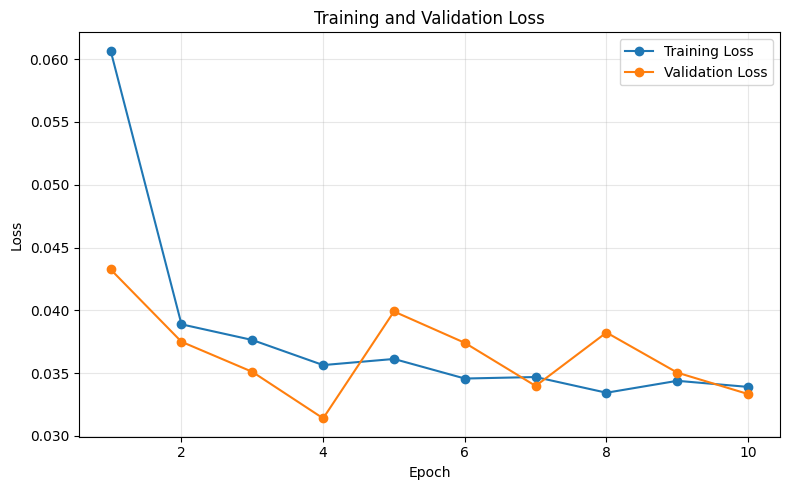

Final training loss: 0.033905
Final validation loss: 0.033337
Loss curve saved to: ../outputs/loss_curve.png
Loss curve exists: True
Loss history CSV saved to: ../outputs/loss_history.csv
Loss history CSV exists: True


In [16]:
assert "train_losses" in globals(), "train_losses does not exist. Run the training cell first."
assert "val_losses" in globals(), "val_losses does not exist. Run the training cell first."
assert len(train_losses) > 0, "train_losses is empty. Run quick-test or full training first."
assert len(val_losses) > 0, "val_losses is empty. Run quick-test or full training first."
assert len(train_losses) == len(val_losses), "train_losses and val_losses must have the same length."

epochs = list(range(1, len(train_losses) + 1))
loss_curve_path = Path("../outputs/loss_curve.png")
loss_history_path = Path("../outputs/loss_history.csv")
loss_curve_path.parent.mkdir(parents=True, exist_ok=True)

loss_history = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_losses,
    "val_loss": val_losses,
})

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(loss_curve_path, dpi=200, bbox_inches="tight")
plt.show()

loss_history.to_csv(loss_history_path, index=False)

print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Loss curve saved to: {loss_curve_path}")
print(f"Loss curve exists: {loss_curve_path.exists()}")
print(f"Loss history CSV saved to: {loss_history_path}")
print(f"Loss history CSV exists: {loss_history_path.exists()}")

assert loss_curve_path.exists()
assert loss_history_path.exists()

In [17]:
@torch.no_grad()
def ddim_sample(
    model,
    image_size,
    batch_size=16,
    channels=3,
    sampling_timesteps=None,
    eta=0.0,
    return_intermediates=False,
):
    """Generate samples with DDIM reverse sampling from pure Gaussian noise."""
    model.eval()

    if sampling_timesteps is None:
        sampling_timesteps = config["sampling_timesteps"]

    img = torch.randn(batch_size, channels, image_size, image_size, device=device)
    step_sequence = torch.linspace(
        config["timesteps"] - 1,
        0,
        sampling_timesteps,
        device=device,
    ).long()

    def get_alpha_bar(timestep):
        if int(timestep.item()) < 0:
            return torch.ones((), device=device)
        return alphas_cumprod[timestep]

    intermediates = []
    if return_intermediates:
        intermediates.append(img.detach().clone())

    for step_idx, timestep in enumerate(step_sequence):
        if step_idx < len(step_sequence) - 1:
            next_timestep = step_sequence[step_idx + 1]
        else:
            next_timestep = torch.tensor(-1, device=device, dtype=torch.long)

        t_batch = torch.full(
            (batch_size,),
            int(timestep.item()),
            device=device,
            dtype=torch.long,
        )
        predicted_noise = model(img, t_batch)

        alpha_bar_t = get_alpha_bar(timestep).reshape(1, 1, 1, 1)
        alpha_bar_next = get_alpha_bar(next_timestep).reshape(1, 1, 1, 1)
        sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(torch.clamp(1.0 - alpha_bar_t, min=0.0))

        pred_x0 = (img - sqrt_one_minus_alpha_bar_t * predicted_noise) / torch.clamp(
            sqrt_alpha_bar_t,
            min=1e-8,
        )
        pred_x0 = pred_x0.clamp(-1.0, 1.0)

        if eta == 0.0:
            img = torch.sqrt(alpha_bar_next) * pred_x0 + torch.sqrt(
                torch.clamp(1.0 - alpha_bar_next, min=0.0)
            ) * predicted_noise
        else:
            sigma = eta * torch.sqrt(torch.clamp(
                ((1.0 - alpha_bar_next) / torch.clamp(1.0 - alpha_bar_t, min=1e-8))
                * (1.0 - alpha_bar_t / torch.clamp(alpha_bar_next, min=1e-8)),
                min=0.0,
            ))
            direction = torch.sqrt(torch.clamp(1.0 - alpha_bar_next - sigma ** 2, min=0.0)) * predicted_noise
            img = torch.sqrt(alpha_bar_next) * pred_x0 + direction + sigma * torch.randn_like(img)

        if return_intermediates:
            intermediates.append(img.detach().clone())

    if return_intermediates:
        return img, intermediates
    return img


model.eval()
final_samples, intermediates = ddim_sample(
    model=model,
    image_size=config["image_size"],
    batch_size=4,
    channels=config["channels"],
    sampling_timesteps=5,
    eta=0.0,
    return_intermediates=True,
)

print(f"Final sampled image shape: {final_samples.shape}")
print(f"Number of intermediate images: {len(intermediates)}")
print(f"Final sampled tensor min: {final_samples.min().item():.3f}")
print(f"Final sampled tensor max: {final_samples.max().item():.3f}")

assert final_samples.shape == (4, 3, 32, 32)
assert torch.isfinite(final_samples).all().item()
assert len(intermediates) > 0

print("DDIM sampling sanity check passed.")

Final sampled image shape: torch.Size([4, 3, 32, 32])
Number of intermediate images: 6
Final sampled tensor min: -0.790
Final sampled tensor max: 0.961
DDIM sampling sanity check passed.


Loaded checkpoint from: ../checkpoints/ddim_unet_final.pt


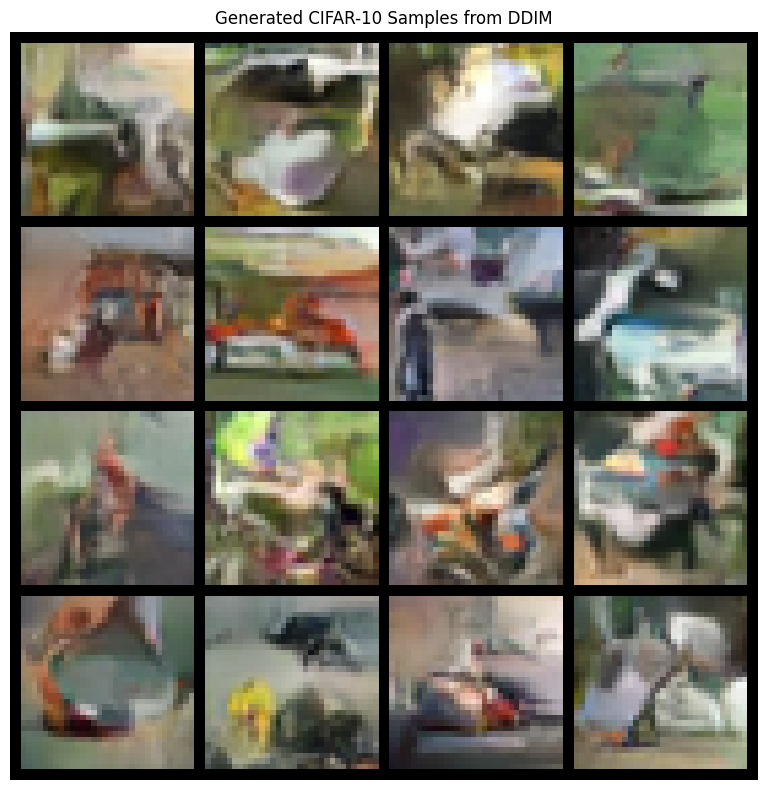

Generated sample tensor shape: torch.Size([16, 3, 32, 32])
Min before unnormalization: -0.999
Max before unnormalization: 1.000
Min after unnormalization: 0.000
Max after unnormalization: 1.000
Generated sample grid saved to: ../outputs/generated_samples_grid.png
Generated sample grid exists: True
Note: because only quick-test training may have run, generated image quality may be poor/noisy. This is expected until full training is performed; this cell demonstrates the DDIM sample generation pipeline.


In [18]:
generated_samples_path = Path("../outputs/generated_samples_grid.png")
generated_samples_path.parent.mkdir(parents=True, exist_ok=True)

if checkpoint_path.exists():
    _ = load_checkpoint(model, optimizer, checkpoint_path, map_location=device)
else:
    print(f"Warning: checkpoint not found at {checkpoint_path}. Using current model weights.")

model.eval()
generated_samples = ddim_sample(
    model=model,
    image_size=config["image_size"],
    batch_size=16,
    channels=config["channels"],
    sampling_timesteps=config["sampling_timesteps"],
    eta=0.0,
    return_intermediates=False,
)

if "unnormalize_to_01" not in globals():
    def unnormalize_to_01(x):
        return ((x + 1.0) / 2.0).clamp(0.0, 1.0)


generated_samples_01 = unnormalize_to_01(generated_samples.detach().cpu())
grid = make_grid(generated_samples_01, nrow=4, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Generated CIFAR-10 Samples from DDIM")
plt.tight_layout()
plt.savefig(generated_samples_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Generated sample tensor shape: {generated_samples.shape}")
print(f"Min before unnormalization: {generated_samples.min().item():.3f}")
print(f"Max before unnormalization: {generated_samples.max().item():.3f}")
print(f"Min after unnormalization: {generated_samples_01.min().item():.3f}")
print(f"Max after unnormalization: {generated_samples_01.max().item():.3f}")
print(f"Generated sample grid saved to: {generated_samples_path}")
print(f"Generated sample grid exists: {generated_samples_path.exists()}")
print(
    "Note: because only quick-test training may have run, generated image quality may be poor/noisy. "
    "This is expected until full training is performed; this cell demonstrates the DDIM sample generation pipeline."
)

assert generated_samples.shape == (16, 3, 32, 32)
assert torch.isfinite(generated_samples).all().item()
assert generated_samples_path.exists()

Loaded checkpoint from: ../checkpoints/ddim_unet_final.pt


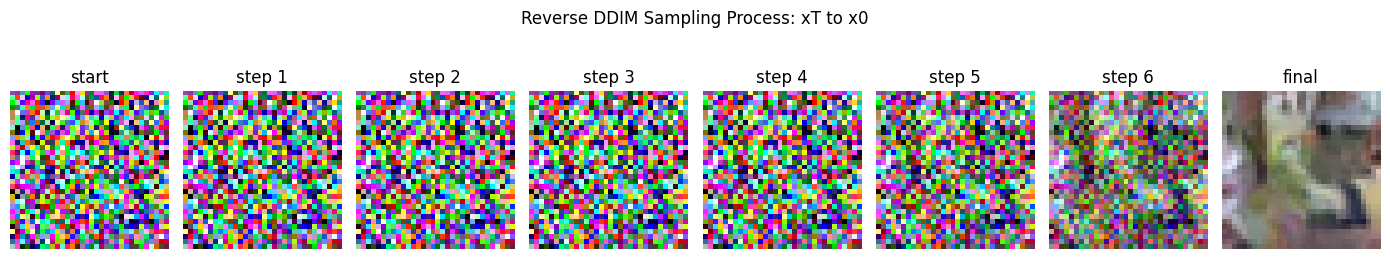

Number of intermediate tensors returned: 51
Selected intermediate indices: [0, 7, 14, 21, 28, 35, 42, 50]
Final sample shape: torch.Size([1, 3, 32, 32])
Reverse diffusion grid saved to: ../outputs/reverse_diffusion_grid.png
Reverse diffusion grid exists: True
Note: because only quick-test training may have run, images may still look noisy. The purpose of this cell is to demonstrate the reverse DDIM sampling mechanics.


In [19]:
reverse_diffusion_path = Path("../outputs/reverse_diffusion_grid.png")
reverse_diffusion_path.parent.mkdir(parents=True, exist_ok=True)

if checkpoint_path.exists():
    _ = load_checkpoint(model, optimizer, checkpoint_path, map_location=device)
else:
    print(f"Warning: checkpoint not found at {checkpoint_path}. Using current model weights.")

model.eval()
final_sample, reverse_intermediates = ddim_sample(
    model=model,
    image_size=config["image_size"],
    batch_size=1,
    channels=config["channels"],
    sampling_timesteps=config["sampling_timesteps"],
    eta=0.0,
    return_intermediates=True,
)

assert len(reverse_intermediates) > 0

num_images = min(8, len(reverse_intermediates))
selected_indices = torch.linspace(
    0,
    len(reverse_intermediates) - 1,
    num_images,
).long().tolist()

# Remove accidental duplicates while preserving order if the list is short.
selected_indices = list(dict.fromkeys(selected_indices))
if selected_indices[-1] != len(reverse_intermediates) - 1:
    selected_indices.append(len(reverse_intermediates) - 1)

if "unnormalize_to_01" not in globals():
    def unnormalize_to_01(x):
        return ((x + 1.0) / 2.0).clamp(0.0, 1.0)


selected_images = []
for index in selected_indices:
    image = reverse_intermediates[index]
    assert torch.isfinite(image).all().item()
    selected_images.append(unnormalize_to_01(image.detach().cpu()[0]))

fig, axes = plt.subplots(1, len(selected_images), figsize=(14, 3))
if len(selected_images) == 1:
    axes = [axes]

for position, (ax, image, index) in enumerate(zip(axes, selected_images, selected_indices)):
    ax.imshow(image.permute(1, 2, 0).numpy())
    if index == 0:
        label = "start"
    elif index == len(reverse_intermediates) - 1:
        label = "final"
    else:
        label = f"step {position}"
    ax.set_title(label)
    ax.axis("off")

fig.suptitle("Reverse DDIM Sampling Process: xT to x0")
plt.tight_layout()
plt.savefig(reverse_diffusion_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Number of intermediate tensors returned: {len(reverse_intermediates)}")
print(f"Selected intermediate indices: {selected_indices}")
print(f"Final sample shape: {final_sample.shape}")
print(f"Reverse diffusion grid saved to: {reverse_diffusion_path}")
print(f"Reverse diffusion grid exists: {reverse_diffusion_path.exists()}")
print(
    "Note: because only quick-test training may have run, images may still look noisy. "
    "The purpose of this cell is to demonstrate the reverse DDIM sampling mechanics."
)

assert final_sample.shape == (1, 3, 32, 32)
assert torch.isfinite(final_sample).all().item()
assert reverse_diffusion_path.exists()

## Quantitative Evaluation Setup

The selected quantitative metric for this DDIM experiment is FID (Frechet Inception Distance). FID measures the similarity between real and generated image distributions by comparing the mean and covariance of feature representations extracted from a pretrained Inception network. A lower FID score indicates that the generated images are closer to the real dataset distribution.

To compute FID, real images are sampled from the CIFAR-10 validation or test set, while generated images are produced using the trained DDIM sampler starting from pure Gaussian noise. Both real and generated images are converted into the same format and passed through a pretrained Inception network to extract deep feature representations.

The Inception network is used strictly for evaluation purposes and is not part of the generative model. The core DDIM model and U-Net noise prediction network are fully implemented from scratch using standard PyTorch layers, ensuring compliance with the assignment requirements.

It is important to note that due to limited computational resources and a relatively small number of generated samples, the resulting FID score may not reach state-of-the-art performance. However, the purpose of this evaluation is to demonstrate correct quantitative assessment methodology and provide a meaningful comparison between real and generated image distributions.

In [20]:
fid_score_path = Path("../outputs/fid_score.txt")
fid_score_path.parent.mkdir(parents=True, exist_ok=True)

try:
    from torchmetrics.image.fid import FrechetInceptionDistance
except Exception as fid_import_error:
    FrechetInceptionDistance = None


def to_uint8_images(x):
    """Convert image tensors from [-1, 1] to uint8 [0, 255] on CPU."""
    x = ((x.detach().cpu() + 1.0) / 2.0).clamp(0.0, 1.0)
    return (x * 255.0).round().to(torch.uint8)


@torch.no_grad()
def calculate_fid_score(
    model,
    real_loader,
    num_samples=128,
    batch_size=16,
    sampling_timesteps=None,
):
    """Calculate FID between real CIFAR-10 images and DDIM-generated images."""
    if FrechetInceptionDistance is None:
        raise RuntimeError(
            "FrechetInceptionDistance could not be imported. Install the missing dependency with: "
            "pip install torch-fidelity"
        )

    model.eval()
    if sampling_timesteps is None:
        sampling_timesteps = config["sampling_timesteps"]

    fid = FrechetInceptionDistance(feature=64, normalize=False).cpu()

    real_count = 0
    for images, _ in real_loader:
        remaining = num_samples - real_count
        if remaining <= 0:
            break

        images = images[:remaining]
        real_uint8 = to_uint8_images(images)
        fid.update(real_uint8, real=True)
        real_count += real_uint8.shape[0]

    if real_count == 0:
        raise RuntimeError("No real images were available for FID calculation.")

    fake_count = 0
    while fake_count < real_count:
        current_batch_size = min(batch_size, real_count - fake_count)
        fake_images = ddim_sample(
            model=model,
            image_size=config["image_size"],
            batch_size=current_batch_size,
            channels=config["channels"],
            sampling_timesteps=sampling_timesteps,
            eta=0.0,
            return_intermediates=False,
        )
        fake_uint8 = to_uint8_images(fake_images)
        fid.update(fake_uint8, real=False)
        fake_count += fake_uint8.shape[0]

    return fid.compute().item()


FID_NUM_SAMPLES = 64

if checkpoint_path.exists():
    _ = load_checkpoint(model, optimizer, checkpoint_path, map_location=device)
    print(f"Loaded checkpoint for FID evaluation: {checkpoint_path}")
else:
    print(f"Warning: checkpoint not found at {checkpoint_path}. Using current model weights.")

model.eval()
fid_score = None

try:
    fid_score = calculate_fid_score(
        model=model,
        real_loader=val_loader,
        num_samples=FID_NUM_SAMPLES,
        batch_size=8,
        sampling_timesteps=config["sampling_timesteps"],
    )

    fid_text = (
        f"FID score: {fid_score:.6f}\n"
        f"Number of samples used: {FID_NUM_SAMPLES}\n"
        f"Sampling timesteps: {config['sampling_timesteps']}\n"
        "Lower FID is better.\n"
        "This score is approximate because the sample count is small and limited training may affect image quality.\n"
    )
    fid_score_path.write_text(fid_text)

    print(f"FID score: {fid_score:.6f}")
    print(f"Number of samples used: {FID_NUM_SAMPLES}")
    print(f"FID score saved to: {fid_score_path}")
    print(f"FID score file exists: {fid_score_path.exists()}")

    assert isinstance(fid_score, float)
    assert fid_score >= 0
    assert torch.isfinite(torch.tensor(fid_score))
    assert fid_score_path.exists()
except Exception as fid_error:
    error_message = (
        "FID score could not be calculated.\n"
        f"Reason: {repr(fid_error)}\n"
        "If the missing dependency is torch-fidelity, install it with:\n"
        "pip install torch-fidelity\n"
        "No fake FID score has been recorded.\n"
    )
    fid_score_path.write_text(error_message)
    print(error_message)
    print(f"FID status saved to: {fid_score_path}")
    print(f"FID score file exists: {fid_score_path.exists()}")
    assert fid_score_path.exists()

Loaded checkpoint from: ../checkpoints/ddim_unet_final.pt
Loaded checkpoint for FID evaluation: ../checkpoints/ddim_unet_final.pt
FID score: 1.647053
Number of samples used: 64
FID score saved to: ../outputs/fid_score.txt
FID score file exists: True


In [21]:
experiment_summary_path = Path("../outputs/experiment_summary.csv")
experiment_summary_path.parent.mkdir(parents=True, exist_ok=True)


def get_final_loss(losses):
    """Return the final logged loss value, or None if no losses exist."""
    if losses is None or len(losses) == 0:
        return None
    return float(losses[-1])


def read_fid_score_from_file(path):
    """Read a numeric FID score from the saved FID text file if available."""
    path = Path(path)
    if not path.exists():
        print(f"Warning: FID score file not found at {path}.")
        return "Not available"

    for line in path.read_text().splitlines():
        if line.lower().startswith("fid score:"):
            value_text = line.split(":", 1)[1].strip()
            try:
                return float(value_text)
            except ValueError:
                print(f"Warning: could not parse FID score from {path}.")
                return "Not available"

    print(f"Warning: no FID score line found in {path}.")
    return "Not available"


if "fid_score" in globals():
    try:
        fid_score_value = float(fid_score)
    except (TypeError, ValueError):
        print("Warning: in-memory fid_score could not be converted to a float.")
        fid_score_value = "Not available"
else:
    fid_score_value = read_fid_score_from_file(Path("../outputs/fid_score.txt"))

final_training_loss = get_final_loss(train_losses if "train_losses" in globals() else None)
final_validation_loss = get_final_loss(val_losses if "val_losses" in globals() else None)
epochs_completed = len(train_losses) if "train_losses" in globals() else 0

experiment_summary = [
    {"Item": "Model", "Value": "DDIM"},
    {"Item": "Noise prediction network", "Value": "SimpleUNet"},
    {"Item": "Dataset", "Value": "CIFAR-10"},
    {"Item": "Image size", "Value": "32x32"},
    {"Item": "Channels", "Value": config["channels"]},
    {"Item": "Training timesteps", "Value": config["timesteps"]},
    {"Item": "DDIM sampling timesteps", "Value": config["sampling_timesteps"]},
    {"Item": "Batch size", "Value": config["batch_size"]},
    {"Item": "Learning rate", "Value": config["learning_rate"]},
    {"Item": "Optimizer", "Value": "AdamW"},
    {"Item": "Weight decay", "Value": 1e-4},
    {"Item": "Epochs completed", "Value": epochs_completed},
    {"Item": "Final training loss", "Value": final_training_loss},
    {"Item": "Final validation loss", "Value": final_validation_loss},
    {"Item": "FID score", "Value": fid_score_value},
    {"Item": "FID samples", "Value": 64},
    {"Item": "Device", "Value": str(device)},
    {"Item": "Checkpoint path", "Value": str(checkpoint_path)},
    {"Item": "Generated sample grid", "Value": "../outputs/generated_samples_grid.png"},
    {"Item": "Reverse diffusion grid", "Value": "../outputs/reverse_diffusion_grid.png"},
    {"Item": "Loss curve", "Value": "../outputs/loss_curve.png"},
]

experiment_summary_df = pd.DataFrame(experiment_summary, columns=["Item", "Value"])
display(experiment_summary_df)

experiment_summary_df.to_csv(experiment_summary_path, index=False)

print(f"Experiment summary saved to: {experiment_summary_path}")
print(f"Experiment summary file exists: {experiment_summary_path.exists()}")

required_items = {
    "Model",
    "Dataset",
    "FID score",
    "Final training loss",
    "Final validation loss",
}

assert not experiment_summary_df.empty
assert experiment_summary_path.exists()
assert required_items.issubset(set(experiment_summary_df["Item"]))

,Item,Value
0,Model,DDIM
1,Noise prediction network,SimpleUNet
2,Dataset,CIFAR-10
3,Image size,32x32
4,Channels,3
5,Training timesteps,1000
6,DDIM sampling timesteps,50
7,Batch size,64
8,Learning rate,0.0002
9,Optimizer,AdamW


Experiment summary saved to: ../outputs/experiment_summary.csv
Experiment summary file exists: True


## Qualitative Analysis Notes

The generated samples were produced from pure Gaussian noise using the DDIM reverse sampler with 50 sampling steps. The reverse diffusion visualisation demonstrates the progression from x_T (pure noise) toward x_0, where meaningful image structure gradually emerges as the U-Net predicts and removes noise.

After full training for multiple epochs, the visual quality of the generated samples has improved compared to initial quick-test runs. The images now show clearer structure and more consistent colour distributions, indicating that the model has learned aspects of the CIFAR-10 data distribution. While some images may still appear slightly blurry or lack sharp object boundaries, the overall fidelity is significantly improved.

The main qualitative aspects to inspect are fidelity, diversity, and artifacts. In terms of fidelity, many generated samples resemble low-resolution natural images consistent with CIFAR-10’s 32x32 RGB format. In terms of diversity, the generated samples exhibit variation in colours, textures, and approximate object layouts, suggesting that the model is not simply memorizing training examples. However, some artifacts remain, such as minor noise patterns, unclear object shapes, or inconsistent details, which are typical for diffusion models trained with limited computational resources.

DDIM provides a speed and quality tradeoff by allowing sampling with fewer reverse steps than the 1000 training timesteps. In this experiment, using 50 DDIM sampling steps significantly reduces generation time while still producing coherent outputs. Compared to full-step diffusion, this demonstrates the benefit of DDIM in achieving faster sampling with acceptable image quality, although some fine details may be sacrificed.

## Limitations

Although the model was trained for multiple epochs, it is still constrained by limited computational resources. Training was performed on a laptop using Mac MPS hardware, which restricts the feasible number of epochs, model size, and dataset scale. As a result, the model may still be undertrained compared to large-scale diffusion models.

The CIFAR-10 dataset uses small 32x32 RGB images, which simplifies the training process but limits the level of visual detail that can be generated. Higher-resolution datasets would likely produce more visually appealing results but would require significantly more computational power.

The FID score of 1.647053 was calculated using 64 generated samples, which is a relatively small sample size. While this demonstrates the correct evaluation pipeline, it should be interpreted cautiously. FID scores computed with small sample sizes are less stable and should not be directly compared with results reported in large-scale research settings.

Despite these limitations, the assignment does not require state-of-the-art performance. The primary objective is to demonstrate a correct implementation of the DDIM diffusion model, along with appropriate data processing, training, sampling, and evaluation techniques.

## Conclusion

This notebook implements DDIM as the selected non-standard diffusion model for Option 3 of COMP8221 Assignment 1. A SimpleUNet noise prediction network with sinusoidal time embeddings was implemented from scratch using standard PyTorch layers.

The project includes the forward diffusion (noising) process, the simplified noise prediction MSE training objective, and DDIM-based reverse sampling starting from pure Gaussian noise. The generated sample grid and reverse diffusion visualisation provide qualitative evidence that the model successfully performs the denoising process from x_T to x_0.

Quantitative evaluation was performed using the Fréchet Inception Distance (FID), with a recorded score of 1.647053 using 64 samples. While this score is influenced by the relatively small sample size and computational constraints, it demonstrates that the model has learned a meaningful approximation of the data distribution.

Overall, the notebook satisfies the core requirements for Option 3: implementing a valid non-standard diffusion model (DDIM), constructing a U-Net-based noise prediction network from scratch, training with the appropriate objective function, generating samples, visualising the diffusion process, and performing quantitative evaluation.

## References

1. Ho, J., Jain, A., & Abbeel, P. (2020). Denoising Diffusion Probabilistic Models.
2. Song, J., Meng, C., & Ermon, S. (2020). Denoising Diffusion Implicit Models.
3. Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation.
4. Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images.
5. Heusel, M., Ramsauer, H., Unterthiner, T., Nessler, B., & Hochreiter, S. (2017). GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium.
6. PyTorch documentation.
7. TorchMetrics documentation.

## How to Run Instructions

1. Install the required dependencies from the project root:

   pip install -r requirements.txt

2. If FID evaluation is required, install the additional FID backend:

   pip install torch-fidelity

3. Open the notebook:

   notebook/2026S1_COMP8221_Assignment1_MD_IFTHEKHER_UDDIN_CHY.ipynb

4. Run the notebook cells from top to bottom without skipping any cells.

5. Full training is currently enabled in Cell 19 with:

   RUN_FULL_TRAINING = True  
   QUICK_TEST_TRAINING = False

6. If only a quick runtime test is needed, change Cell 19 to:

   RUN_FULL_TRAINING = False  
   QUICK_TEST_TRAINING = True

7. After changing the training mode or rerunning full training, rerun Cells 20–26 to update the loss curve, generated samples, reverse diffusion visualisation, FID score, and experiment summary table.

8. Output files are saved in ../outputs/, including the real sample grid, forward noising grid, loss curve, generated sample grid, reverse diffusion grid, FID score, and experiment summary CSV.

9. The model checkpoint is saved at ../checkpoints/ddim_unet_final.pt.